Part 1: Analyzing Best-Seller Trends Across Product Categories
Objective: Understand the relationship between product categories and their best-seller status.

1- Crosstab Analysis:

Create a crosstab between the product category and the isBestSeller status.

Are there categories where being a best-seller is more prevalent?

Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import numpy as np

# Cargar los datos
df = pd.read_csv('amz_uk_price_prediction_dataset.csv')

# Create the crosstab
ct = pd.crosstab(df['category'], df['isBestSeller'])

# Calculate the proportion (percentage) of best-sellers
# We divide the 'True' column by the total sum of that row
ct_proportions = pd.crosstab(df['category'], df['isBestSeller'], normalize='index')

# Sort to see which category has the highest percentage of best-sellers
best_seller_rate = ct_proportions[True].sort_values(ascending=False)
print(best_seller_rate.head(10))



category
Grocery                           0.058135
Smart Home Security & Lighting    0.057692
Health & Personal Care            0.057686
Mobile Phone Accessories          0.042471
Power & Hand Tools                0.035339
Billiard, Snooker & Pool          0.032129
Pet Supplies                      0.030200
Home Brewing & Wine Making        0.028455
Wind Instruments                  0.028000
Mirrors                           0.028000
Name: True, dtype: float64


2- Statistical Tests:

Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
Compute Cramér's V to understand the strength of association between best-seller status and category.

In [7]:
# Chi-Square
chi2, p, dof, expected = chi2_contingency(ct)
print(f"P-Value: {p}")

# Cramér's V Function
def calculate_cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))

print(f"Cramér's V: {calculate_cramers_v(ct)}")

P-Value: 0.0
Cramér's V: 0.1222829439760564


3- Visualizations:

Visualize the relationship between product categories and the best-seller status using a stacked bar chart.

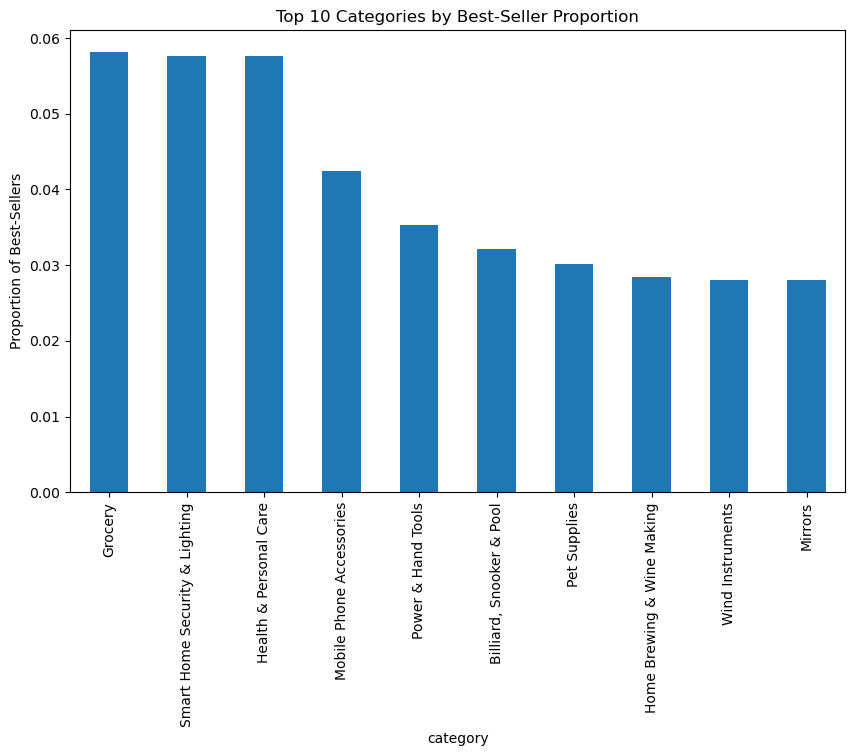

In [8]:
# Plotting the top 10 categories for clarity
best_seller_rate.head(10).plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Top 10 Categories by Best-Seller Proportion')
plt.ylabel('Proportion of Best-Sellers')
plt.show()

Part 2: Exploring Product Prices and Ratings Across Categories and Brands
Objective: Investigate how different product categories influence product prices.

0- Preliminary Step: Remove outliers in product prices.

For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.

Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.


In [9]:
# Calculate Q1, Q3, and IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Create the filtered DataFrame
df_clean = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)].copy()

print(f"Original rows: {len(df)}")
print(f"Rows after removing outliers: {len(df_clean)}")

Original rows: 2443651
Rows after removing outliers: 2115963


1- Violin Plots:

Use a violin plot to visualize the distribution of price across different product categories. Filter out the top 20 categories based on count for better visualization.
Which product category tends to have the highest median price? Don't filter here by top categories.

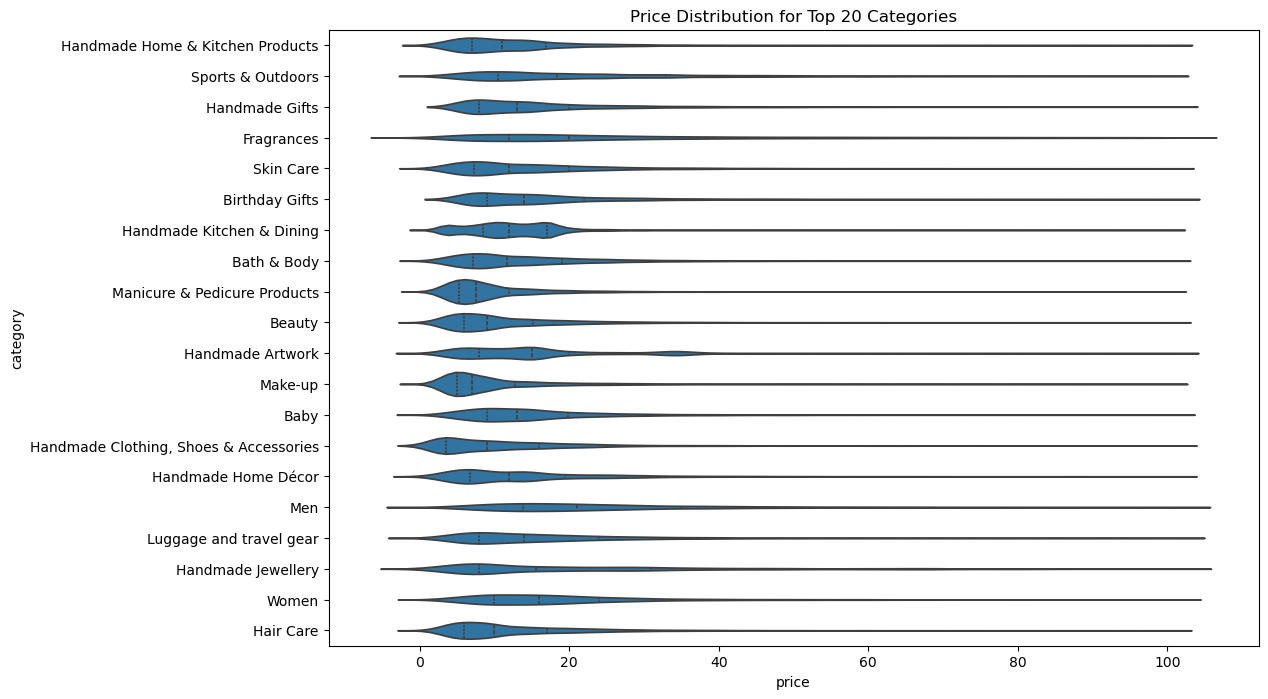

Category with highest median price: Desktop PCs


In [10]:
# Get the top 20 categories by count
top_20_cats = df_clean['category'].value_counts().nlargest(20).index
df_top20 = df_clean[df_clean['category'].isin(top_20_cats)]

# Visualization
plt.figure(figsize=(12, 8))
sns.violinplot(data=df_top20, x='price', y='category', inner='quartile')
plt.title('Price Distribution for Top 20 Categories')
plt.show()

# Finding the highest median price (unfiltered)
highest_median_price_cat = df_clean.groupby('category')['price'].median().sort_values(ascending=False).idxmax()
print(f"Category with highest median price: {highest_median_price_cat}")

2- Bar Charts:

Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
Which product category commands the highest average price? Don't filter here by top categories.

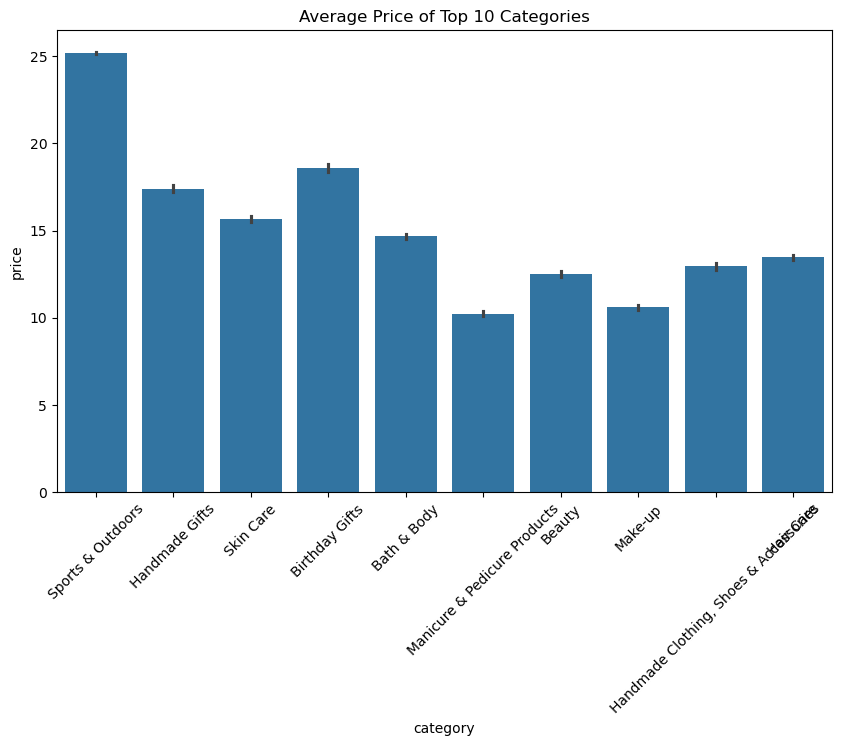

Category with highest average price: Motherboards


In [11]:
# Top 10 categories for the chart
top_10_cats = df_clean['category'].value_counts().nlargest(10).index
df_top10 = df_clean[df_clean['category'].isin(top_10_cats)]

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=df_top10, x='category', y='price', estimator='mean')
plt.xticks(rotation=45)
plt.title('Average Price of Top 10 Categories')
plt.show()

# Highest average price (unfiltered)
highest_avg_price_cat = df_clean.groupby('category')['price'].mean().idxmax()
print(f"Category with highest average price: {highest_avg_price_cat}")

3- Box Plots:

Visualize the distribution of product ratings based on their category using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
Which category tends to receive the highest median rating from customers? Don't filter here by top categories.

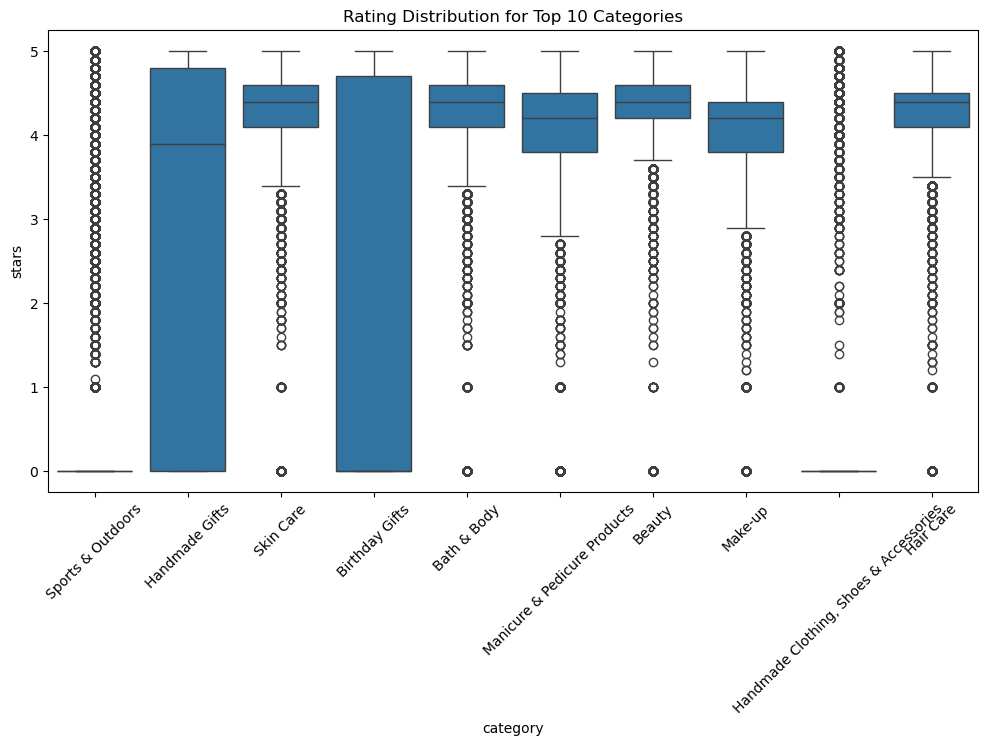

Category with highest median rating: Computer Memory


In [12]:
# Top 10 categories for the chart
df_ratings_top10 = df_clean[df_clean['category'].isin(top_10_cats)]

# Visualization
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_ratings_top10, x='category', y='stars')
plt.xticks(rotation=45)
plt.title('Rating Distribution for Top 10 Categories')
plt.show()

# Highest median rating (unfiltered)
highest_median_rating_cat = df_clean.groupby('category')['stars'].median().idxmax()
print(f"Category with highest median rating: {highest_median_rating_cat}")

Part 3: Investigating the Interplay Between Product Prices and Ratings
Objective: Analyze how product ratings (stars) correlate with product prices.

1- Correlation Coefficients:

Calculate the correlation coefficient between price and stars.
Is there a significant correlation between product price and its rating?

In [13]:
# Correlation between price and stars
correlation = df_clean['price'].corr(df_clean['stars'])
print(f"Correlation between Price and Stars: {correlation:.4f}")

Correlation between Price and Stars: -0.0777


2- Visualizations:

Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
Use a correlation heatmap to visualize correlations between all numerical variables.
Examine if product prices typically follow a normal distribution using a QQ plot.

In [ ]:
#A Scatter Plot lets us see the raw data points, while a Heatmap shows us the "big picture" of how all numbers in our dataset relate to each other.

# Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='price', y='stars', alpha=0.3)
plt.title('Relationship between Price and Ratings')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

3. Normality Check (The QQ Plot)
A Quantile-Quantile (QQ) Plot compares your data's distribution against a theoretical normal distribution (a straight line).

If the blue dots follow the red line, the data is Normal.

If they curve away significantly, the data is Skewed.

In [ ]:
import statsmodels.api as sm

# QQ Plot for Price
plt.figure(figsize=(8, 6))
sm.qqplot(df_clean['price'], line='s')
plt.title('QQ Plot for Product Prices')
plt.show()